# 📊 Online Course Completion Prediction

This project uses XGBoost to predict whether a student will complete an online course based on learning behavior.

## 🎯 Objective
Predict student course completion to help platforms provide early intervention.

## 📂 Features
- video_count
- quiz_count
- login_days

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import expit
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

## 🧪 Data Generation

We simulate student learning behavior using Poisson distributions:

- video_count ~ Poisson(10)
- quiz_count ~ Poisson(5)
- login_days ~ Poisson(7)

A hidden logistic model is used to generate completion probability.

In [4]:
# 建立資料夾（避免存檔報錯）
os.makedirs("data", exist_ok=True)
os.makedirs("images", exist_ok=True)

# 產生模擬資料
np.random.seed(23)
n = 300

video_count = np.random.poisson(lam=10, size=n)
quiz_count = np.random.poisson(lam=5, size=n)
login_days = np.random.poisson(lam=7, size=n)

# 隱藏的線性邏輯機率模型
logit = (
    -4.0
    + 0.18 * video_count
    + 0.30 * quiz_count
    + 0.22 * login_days
)

# sigmoid 轉機率
prob = expit(logit)

# 根據機率產生 completed 標籤（0/1）
completed = np.random.binomial(1, prob)

# 建立 DataFrame
df = pd.DataFrame({
    "video_count": video_count,
    "quiz_count": quiz_count,
    "login_days": login_days,
    "completed": completed
})

# 存成 CSV
df.to_csv("data/simulated_data.csv", index=False)

In [5]:
df.head()

,video_count,quiz_count,login_days,completed
0,13,1,5,1
1,7,4,10,1
2,6,5,7,0
3,11,5,6,1
4,14,7,4,0


## ✂️ Train-Test Split

The dataset is split into:
- 80% training set
- 20% testing set

Random state is fixed at 23 for reproducibility.

In [6]:
X = df[["video_count", "quiz_count", "login_days"]]
y = df["completed"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=23
)

print(f"訓練集筆數：{len(X_train)}")
print(f"測試集筆數：{len(X_test)}")

訓練集筆數：240
測試集筆數：60


## 🤖 Model Training

We use XGBoost for binary classification with the following parameters:

- n_estimators = 100
- learning_rate = 0.1
- max_depth = 4
- objective = "binary:logistic"

In [7]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=23
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=23, ...)

## 📈 Model Evaluation

We use accuracy to evaluate model performance on the test set.

In [8]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.3f}")

Model Accuracy: 0.767


## 📊 Feature Importance

We inspect feature importance using `feature_importances_` from the trained XGBoost model.

In [9]:
importances = model.feature_importances_

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

importance_df

,feature,importance
0,video_count,0.43939
1,quiz_count,0.33041
2,login_days,0.23020


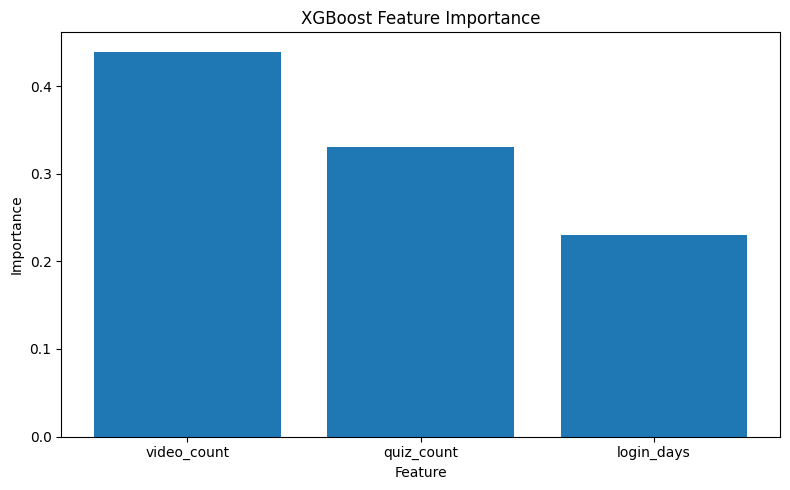

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(importance_df["feature"], importance_df["importance"])
plt.title("XGBoost Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("images/feature_importance.png")
plt.show()

## 📈 Result

- Model Accuracy: 0.767
- Most Important Feature: video_count

## 💡 Insight

Students who watch more videos are more likely to complete the course, indicating that learning engagement is an important predictor.

## 🚀 Future Work

- Add more behavioral features such as watch time, quiz scores, assignment submission count, and discussion activity
- Compare XGBoost with other models such as Logistic Regression and Random Forest
- Use real-world student learning data